# 8.3.2 软阈值与近端梯度

## 学习目标与先修知识

由绝对值惩罚推导软阈值（soft thresholding），显式实现近端梯度（proximal gradient）并核验边界。

先修：8.3.1的正则目标、8.2梯度（gradient）下降与步长。 [本篇学习次序](../README.md)。

## 具体问题

如果候选清除机制很多，我们希望得到较少非零系数。绝对值在0处不可导，怎样既保留这个折点又能逐步求解？

In [1]:
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]
BLUE, PINK, GREEN, GRAY = "#327cac", "#c35178", "#338b7c", "#68768a"

## 初步实验

In [2]:
v=np.array([-2.,-.5,0.,.5,2.]);tau=.5
print('先观察标量目标：')
for center in v:
    z=np.linspace(-3,3,12001);j=(z-center)**2/2+tau*np.abs(z)
    print('v=',center,'网格最小点≈',z[j.argmin()])

先观察标量目标：
v= -2.0 网格最小点≈ -1.5
v= -0.5 网格最小点≈ 0.0
v= 0.0 网格最小点≈ 0.0
v= 0.5 网格最小点≈ 0.0
v= 2.0 网格最小点≈ 1.5


## 模型假设

线性候选字典X固定，观测（observation）y已缩放，目标为平均平方损失加λ倍L1范数（norm），λ≥0。系数无约束，截距固定为零。一般相关字典中系数解可能不唯一；本节只在正交（orthogonality）设计的核验例中使用逐坐标闭式最优解。

## 数学解释与推导


先解标量近端子问题 $\min_z (z-v)^2/2+\tau|z|$。在 $z>0$，导数（derivative）为 $z-v+\tau$，候选 $z=v-\tau$ 仅在 $v>\tau$ 合法；在 $z<0$，候选 $z=v+\tau$ 要求 $v<-\tau$。
0处的次梯度（subgradient）为 $\partial|z|_{z=0}=[-1,1]$；$0\in-v+\tau[-1,1]$ 等价于 $|v|\le\tau$。
三种情况合成软阈值
$$S_\tau(v)=\operatorname{sign}(v)\max(|v|-\tau,0).$$
等于阈值时归零；$\tau=0$ 则恒等。严格凸的平方项保证这个子问题唯一。

写 $F(\beta)=g(\beta)+\lambda\|\beta\|_1$，$g=\|X\beta-y\|^2/(2n)$。
光滑部分梯度是 $X^T(X\beta-y)/n$，最大曲率 $L=\lambda_{\max}(X^TX/n)$。
当 $L>0$ 且 $0<\eta\le1/L$ 时，
$$g(z)\le g(\beta)+\nabla g(\beta)^T(z-\beta)+\frac{\|z-\beta\|^2}{2\eta}.$$
配方后最小化这个上界加惩罚，就得到近端梯度
$$\beta^+=S_{\eta\lambda}\bigl(\beta-\eta\nabla g(\beta)\bigr).$$
新点使上界不大于在旧点的值，因此 $F(\beta^+)\le F(\beta)$。固定满足条件的步长、凸目标且最小点存在时，迭代收敛到一个最小点；不保证支持集合代表真实机制。
$X=0$ 时 $L=0$，光滑部分为常数，可取任意正步长；不可计算 $1/0$。

非光滑目标的最优性是 $0\in\nabla g+\lambda\partial\|\beta\|_1$，不是 $\nabla g=0$。
可检查近端梯度映射 $(\beta-\beta^+)/\eta$。若 $X^TX/n=I$，全局最小点就是 $S_\lambda(X^Ty/n)$；相关设计不能直接用这个公式。


## 核心实现

按上述推导逐步计算；保留明确的更新预算与返回标签。

In [3]:
def soft_threshold(values, threshold):
    return [math.copysign(max(abs(value)-threshold, 0.), value) if abs(value)>threshold else 0.
            for value in values]


def proximal_step(design, observed, coefficients, step, penalty):
    count = len(design)
    residuals = [sum(x*b for x, b in zip(row, coefficients))-y
                 for row, y in zip(design, observed)]
    gradient = [sum(row[j]*r for row, r in zip(design, residuals))/count
                for j in range(len(coefficients))]
    updated = soft_threshold([b-step*g for b, g in zip(coefficients, gradient)], step*penalty)
    errors = [sum(x*b for x, b in zip(row, updated))-y for row, y in zip(design, observed)]
    value = sum(r*r for r in errors)/(2*count)+penalty*sum(abs(b) for b in updated)
    return updated, value


def proximal_trace(design, observed, initial, step, penalty, steps):
    history = [list(initial)]
    objectives = [proximal_step(design, observed, initial, 0., penalty)[1]]
    for _ in range(steps):
        point, value = proximal_step(design, observed, history[-1], step, penalty)
        history.append(point); objectives.append(value)
    return history, objectives

## 对照实验

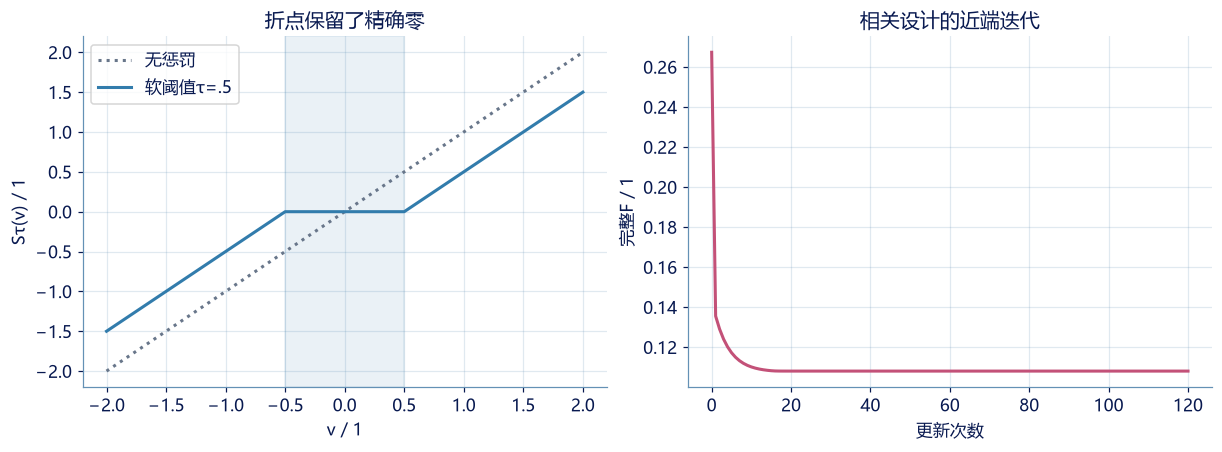

最终系数 [0.7826923076923077, 0.0]
最大目标上升 1.3877787807814457e-17


In [4]:
X=np.array([[1.,.8],[.2,1.],[-1.,-.8],[-.2,-1.]])
y=X@np.array([1.,0.]) + np.array([.02,-.03,-.02,.03]);lam=.12
L=np.linalg.eigvalsh(X.T@X/len(y))[-1];eta=1/L
path,values=proximal_trace(X.tolist(),y.tolist(),[0.,0.],eta,lam,120)
fig,axes=plt.subplots(1,2,figsize=(11,4))
v=np.linspace(-2,2,401);axes[0].plot(v,v,ls=':',color=GRAY,label='无惩罚')
axes[0].plot(v,soft_threshold(v,.5),color=BLUE,label='软阈值τ=.5');axes[0].axvspan(-.5,.5,color=BLUE,alpha=.1)
axes[0].set(xlabel='v / 1',ylabel='Sτ(v) / 1',title='折点保留了精确零');axes[0].legend()
axes[1].plot(values,color=PINK);axes[1].set(xlabel='更新次数',ylabel='完整F / 1',title='相关设计的近端迭代');plt.show()
print('最终系数',path[-1]);print('最大目标上升',np.max(np.diff(values)))

### 独立核验与边界

In [5]:
np.testing.assert_allclose(soft_threshold([-1.,-.5,0.,.5,1.],.5),[-.5,0.,0.,0.,.5])
assert soft_threshold([],1.)==[]
assert np.max(np.diff(values))<=1e-12
X0=np.array([[1.,1.],[1.,-1.]]);y0=np.array([2.,0.])
trace,objectives=proximal_trace(X0.tolist(),y0.tolist(),[0.,0.],1.,.5,2)
np.testing.assert_allclose(trace[-1],[.5,.5]);assert abs(objectives[-1]-.75)<1e-12
beta=np.array(path[-1]);gradient=X.T@(X@beta-y)/len(y)
residual=np.where(np.abs(beta)>1e-9,np.abs(gradient+lam*np.sign(beta)),np.maximum(np.abs(gradient)-lam,0))
print('逐坐标次梯度残差',residual)
assert np.max(residual)<1e-7

逐坐标次梯度残差 [1.38777878e-17 0.00000000e+00]


## 结果解释

软阈值使小坐标精确归零。相关字典的解来自重复更新，不能把正交闭式公式照搬过去。稀疏性是给定尺度、惩罚与数据的结果；若两个机制高度相关，选择哪个可能并不稳定。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：实现逐坐标软阈值

求每个坐标上的最小点argmin_z (z−v)²/2+τ|z|。

**函数与代码模板**

```python
def solve(
    values: list[float],
    threshold: float,
) -> list[float]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 给定坐标v，可为空。 | 无量纲 |
| `threshold` | `float` | 阈值τ。 | 无量纲 |

**返回值**

直接返回 minimizers（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `minimizers` | `list[float]` | 逐坐标最小点，顺序与values一致。 | 无量纲 |

**计算规则**

v>τ时返回v−τ；v<−τ时返回v+τ；其余返回0。边界|v|=τ归零。

**约束与边界**

- 0≤threshold≤10；values长度0—50；元素绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| values | 给定坐标v，可为空。 | [-2.0, -0.5, 0.0, 0.5, 2.0] | 无量纲 |
| threshold | 阈值τ。 | 0.5 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
values = [-2.0, -0.5, 0.0, 0.5, 2.0]
threshold = 0.5

result = solve(values, threshold)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| minimizers | 逐坐标最小点，顺序与values一致。 | [-1.5, 0.0, 0.0, 0.0, 1.5] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [-1.5, 0.0, 0.0, 0.0, 1.5]
```

**样例解释**

两端各向零移动.5；刚好等于阈值的±.5也变为0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：实现逐坐标软阈值](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-threshold)

### 第 2 题 · Python 计算题：计算一次近端更新

对目标F(β)=‖Xβ−y‖²/(2n)+λ‖β‖₁，执行一次近端梯度（proximal gradient）并计算新点的完整目标。

**函数与代码模板**

```python
def solve(
    design: list[list[float]],
    observed: list[float],
    coefficients: list[float],
    step: float,
    penalty: float,
) -> tuple[list[float], float]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `design` | `list[list[float]]` | 设计矩阵（design matrix）X，每行对应一次观测（observation）。 | 无量纲 |
| `observed` | `list[float]` | 同序目标y，已按参考量除去单位。 | 无量纲 |
| `coefficients` | `list[float]` | 当前系数β。 | 无量纲 |
| `step` | `float` | 近端梯度步长η。 | 无量纲 |
| `penalty` | `float` | 惩罚强度λ，与平均平方损失的归一化配套。 | 无量纲 |

**返回值**

按以下顺序返回元组：(updated, objective)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `updated` | `list[float]` | 更新后的β。 | 无量纲 |
| `objective` | `float` | 新点的F值，含L1惩罚。 | 无量纲 |

**计算规则**

先算g=Xᵀ(Xβ−y)/n，再对β−ηg用阈值ηλ做软阈值（soft thresholding）。目标在新点计算。

**约束与边界**

- 2列；1≤n≤20；0≤λ≤3；0<step≤2；本题只要求一步计算，不宣称任意步长都收敛。
- 设计矩阵、观测、初始或当前系数均为有限实数，元素绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| design | 设计矩阵（design matrix）X，每行对应一次观测（observation）。 | [[1.0, 0.0], [0.0, 1.0]] | 无量纲 |
| observed | 同序目标y，已按参考量除去单位。 | [2.0, -0.4] | 无量纲 |
| coefficients | 当前系数β。 | [0.0, 0.0] | 无量纲 |
| step | 近端梯度步长η。 | 1 | 无量纲 |
| penalty | 惩罚强度λ，与平均平方损失的归一化配套。 | 0.3 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
design = [[1.0, 0.0], [0.0, 1.0]]
observed = [2.0, -0.4]
coefficients = [0.0, 0.0]
step = 1.0
penalty = 0.3

result = solve(design, observed, coefficients, step, penalty)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| updated | 更新后的β。 | [0.7, 0.0] | 无量纲 |
| objective | 新点的F值，含L1惩罚。 | 0.6725 | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.7, 0.0], 0.6725)
```

**样例解释**

梯度（gradient）为[−1,.2]，阈值.3，更新得[.7,0]；完整目标为.6725。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算一次近端更新](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-proximal)

### 第 3 题 · 单项选择题：零处的斜率如何表达

最小化(z−v)²/2+τ|z|，τ>0。关于v的哪个条件与“z=0是最小点”等价？

- **A.** 仅当v=0。
- **B.** |v|≤τ。
- **C.** |v|≥τ。
- **D.** 绝对值在0不可导，所以没有最小点。

[作答：零处的斜率如何表达](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-subgradient-zero)

### 第 4 题 · 单项选择题：近端步长和归一化

g(β)=‖Xβ−y‖²/(2n)，L为XᵀX/n的最大特征值（eigenvalue）且L>0。哪种选择保证标准上界模型（model）成立？

- **A.** 0<η≤1/L。
- **B.** η=1，与X无关。
- **C.** 阈值永远用λ，不乘η。
- **D.** 只要加入L1惩罚就不需要检查步长。

[作答：近端步长和归一化](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-proximal-step-size)

### 第 5 题 · 多项选择题：零系数不是机制证明

两个高度相关变量可相互替代，L1解仅保留其中一个。哪些结论合理？

- **A.** 已证明被删变量没有任何生理作用。
- **B.** 这是当前目标和字典下的一种稀疏表示。
- **C.** 需要独立数据和机制证据检查解释。
- **D.** 改变变量尺度或轻微改变数据，入选集合可能变化。

[作答：零系数不是机制证明](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-sparse-evidence)

### 延伸阅读

[Parikh 与 Boyd：Proximal Algorithms，§4.2、§6.5.2](https://web.stanford.edu/~boyd/papers/prox_algs.html)，第4.2节的近端梯度与第6.5.2节的L1近端算子。

[概念探索与交互](http://127.0.0.1:8000/chapters/08-03-正则化与稀疏优化/explore/) · [本篇目录](../README.md)